# RQ1 — Can NLP automatically identify eligibility requirements in art open calls?

**Task.** Classify each sentence ("chunk") of an open call's `requirements_text_en` into one of 9 eligibility labels:
`RESIDENCE`, `NATIONALITY`, `AGE`, `DISCIPLINE`, `CAREER_STAGE`, `EDUCATION`, `STUDENT_STATUS`, `OTHER_ELIGIBILITY`, `NONE`
(definitions and edge-case rules: `ANNOTATION_GUIDELINES.md`).

**Data.** `dataset/labels/eligibility_annotations.csv` — 292 labeled chunks from 79 opportunities, 11–70 chunks per class.

**Validation.** 5-fold `StratifiedGroupKFold`, grouped by opportunity, so no call's chunks are split across train and test.
Headline metric: macro-F1, which weights every class equally despite the imbalance.

**Models**, each compared on the same folds:

| # | Model | Role |
|---|---|---|
| 1 | TF-IDF + Logistic Regression | baseline, product candidate |
| 2 | TF-IDF + Linear SVM | product candidate |
| 3 | Sentence embeddings (`bge-base-en-v1.5`) + Logistic Regression | product candidate |
| 4 | OpenAI LLM, few-shot | reference point only, not a product candidate |

The baseline's error analysis comes right after model 1: it drove a label audit and the removal of heading chunks (`ANNOTATION_GUIDELINES.md` §6), and it explains why model 3 was expected to help.


In [1]:
import os

import pandas as pd

REPO_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(REPO_ROOT, "dataset", "labels", "eligibility_annotations.csv")

df = pd.read_csv(DATA_PATH)
df.shape

(292, 6)

In [2]:
df["label"].value_counts()

label
OTHER_ELIGIBILITY    70
DISCIPLINE           60
NONE                 50
RESIDENCE            36
CAREER_STAGE         21
STUDENT_STATUS       17
NATIONALITY          15
EDUCATION            12
AGE                  11
Name: count, dtype: int64

In [3]:
df.groupby("opportunity_id").size().sort_values(ascending=False).head(10)

opportunity_id
mondriaan_fund_e52bef22781c                    22
national_culture_fund_bulgaria_8fca12fac738    15
kulturdirektoratet_norway_e1b48f36972d         14
dgartes_portugal_111bdc1e2ebf                  10
mondriaan_fund_a939eddff305                     9
creative_ireland_e896d7db1d6a                   9
dansateliers_rotterdam_e3404a6adf78             9
dansateliers_rotterdam_33931cad7e6f             8
kunsten_be_flanders_217b1f327dad                8
fpu_slovakia_c225bfd4c2a2                       7
dtype: int64

In [4]:
# 5 folds, grouped by opportunity so no call's chunks split across train/test
from sklearn.model_selection import StratifiedGroupKFold

X = df["chunk_text"]
y = df["label"]
groups = df["opportunity_id"]

# needs both: GroupKFold alone ignores the 9-class imbalance, StratifiedKFold alone
# would leak an opportunity's shared phrasing across train/test
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
all_labels = set(y.unique())

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    train_groups = set(groups.iloc[train_idx])   # distinct opportunities in train
    test_groups = set(groups.iloc[test_idx])     # distinct opportunities in test
    overlap = train_groups & test_groups          # opportunities present on both sides
    assert not overlap, f"fold {fold}: group leakage on {overlap}"

    # smallest classes (AGE=11, EDUCATION=12) may still miss a fold's test split
    missing = all_labels - set(y.iloc[test_idx])
    print(f"fold {fold}: train={len(train_idx):3d}  test={len(test_idx):3d}  "
          f"missing_from_test={sorted(missing) or 'none'}")

fold 0: train=233  test= 59  missing_from_test=none
fold 1: train=235  test= 57  missing_from_test=none
fold 2: train=231  test= 61  missing_from_test=none
fold 3: train=236  test= 56  missing_from_test=none
fold 4: train=233  test= 59  missing_from_test=none


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_text = df[["chunk_text"]]  # DataFrame, not Series — ColumnTransformer needs a column name to select

baseline = Pipeline([
    # single-column selector: ColumnTransformer hands TfidfVectorizer a 1D array when given a bare column name
    ("features", ColumnTransformer([("tfidf", TfidfVectorizer(), "chunk_text")])),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [1, 2, 3],
    "clf__C": [0.1, 1, 10],
}

# scoring=f1_macro, not accuracy — every class weighted equally despite the 6.5x imbalance
grid = GridSearchCV(baseline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_text, y, groups=groups)

print("best params:", grid.best_params_)
print("best macro-F1 (mean over folds):", grid.best_score_)

best params: {'clf__C': 10, 'features__tfidf__min_df': 1, 'features__tfidf__ngram_range': (1, 1)}
best macro-F1 (mean over folds): 0.6250676215119533


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# out-of-fold predictions for the whole corpus, using the best hyperparameters found above
y_pred = cross_val_predict(grid.best_estimator_, X_text, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, y_pred))

# ANNOTATION_GUIDELINES.md §2 menu order, for a readable confusion matrix
LABEL_ORDER = ["RESIDENCE", "NATIONALITY", "AGE", "DISCIPLINE", "CAREER_STAGE",
               "EDUCATION", "STUDENT_STATUS", "OTHER_ELIGIBILITY", "NONE"]

cm = confusion_matrix(y, y_pred, labels=LABEL_ORDER)
pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)

                   precision    recall  f1-score   support

              AGE       1.00      0.82      0.90        11
     CAREER_STAGE       0.75      0.71      0.73        21
       DISCIPLINE       0.55      0.60      0.57        60
        EDUCATION       0.62      0.42      0.50        12
      NATIONALITY       0.67      0.53      0.59        15
             NONE       0.42      0.48      0.45        50
OTHER_ELIGIBILITY       0.58      0.64      0.61        70
        RESIDENCE       0.71      0.61      0.66        36
   STUDENT_STATUS       0.92      0.65      0.76        17

         accuracy                           0.60       292
        macro avg       0.69      0.61      0.64       292
     weighted avg       0.62      0.60      0.60       292



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,22,0,0,4,1,0,0,5,4
NATIONALITY,1,8,0,3,0,0,0,1,2
AGE,0,0,9,0,0,0,0,1,1
DISCIPLINE,2,1,0,36,2,1,0,9,9
CAREER_STAGE,1,0,0,3,15,0,0,1,1
EDUCATION,0,0,0,3,1,5,1,1,1
STUDENT_STATUS,0,1,0,0,0,2,11,2,1
OTHER_ELIGIBILITY,3,1,0,7,0,0,0,45,14
NONE,2,1,0,10,1,0,0,12,24


In [8]:
# Known limitations of this TF-IDF baseline behind the NONE <-> DISCIPLINE errors
# (bare-heading chunks, a third cause, were removed from the data - ANNOTATION_GUIDELINES.md SS6):
#  1. arts vocabulary in non-constraint sentences - project/delivery descriptions
#     ("work with ... arts, cultural or creative organisations") are NONE but share
#     DISCIPLINE's words; bag-of-words can't tell "the project involves X" from
#     "the applicant must be X"
#  2. discipline terms too rare to learn - "early music", "costume designers",
#     "circus artists" appear once or twice in the corpus, and TF-IDF has no notion
#     that "dancers" ~ "performers", so an unseen term carries no signal -> NONE
# both motivate the sentence-embedding classifier; see flows.md, "Eligibility classifier"
# the confusion matrix's densest error cluster: DISCIPLINE / OTHER_ELIGIBILITY / NONE mixing with each other
confused = {"NONE", "DISCIPLINE", "OTHER_ELIGIBILITY"}
errors = df.assign(pred=y_pred)
errors = errors[(errors["label"] != errors["pred"])
                & errors["label"].isin(confused) & errors["pred"].isin(confused)]

for (true_label, pred_label), group in errors.groupby(["label", "pred"]):
    print(f"\n=== true={true_label}  predicted={pred_label}  (n={len(group)}) ===")
    for text in group["chunk_text"].head(3):
        print(f"  - {text}")


=== true=DISCIPLINE  predicted=NONE  (n=9) ===
  - We are inviting anyone to send us a proposal to create a performance, character or small happening around the (social) aspects of drinking tea (ceremonial, historical, colonial, its gossipy aspect etc) to be presented during our Dress-up-tea-Party.
  - For the ‘Dress-up’ part of our party, we welcome fashion- & costume designers to send a proposal of a selection of pieces/ costumes (from their oeuvre) to be used during the Dress-Up-Tea-Party.
  - Multidisciplinary projects are also welcome.

=== true=DISCIPLINE  predicted=OTHER_ELIGIBILITY  (n=9) ===
  - The Rencontres d’Arles curatorial research grant is aimed at exhibition curators wishing to carry out an original project relating to image or photography.
  - Marta & Kim are searching for a total of 2 additional performers, who meet the following conditions:
  - In addition, the embassy welcomes projects that explore innovative formats and presentation methods, cross-border cultural

In [9]:
pd.set_option("display.max_colwidth", 120)

# confident-error ranking: misclassifications where the model was most sure of a
# *different* label are the best candidates for a real annotation mistake, not
# just a hard/ambiguous chunk the model was unsure about
proba = cross_val_predict(grid.best_estimator_, X_text, y, cv=cv, groups=groups,
                           method="predict_proba", n_jobs=-1)
classes = grid.best_estimator_.classes_
confidence = proba.max(axis=1)
pred_label = classes[proba.argmax(axis=1)]

review = df.assign(pred=pred_label, confidence=confidence)
review = review[review["label"] != review["pred"]].sort_values("confidence", ascending=False)
review[["chunk_id", "chunk_text", "label", "pred", "confidence"]].head(20)

,chunk_id,chunk_text,label,pred,confidence
36,kunsten_be_flanders_1c78c30f66d3_0,"Eligible for support are Dutch-Belgian co-projects across all disciplines, but special attention is given to the per...",RESIDENCE,DISCIPLINE,0.808611
165,u_jazdowski_warsaw_ea8781efb99b_0,"Open call for Palestinian artists , cultural practitioners , theorists , curators , and people working at the inters...",NATIONALITY,DISCIPLINE,0.693019
221,kunst_dk_denmark_028cc37c2d3b_4,Events with audiences must be available to the public and they must be clearly announced.,NONE,OTHER_ELIGIBILITY,0.670228
66,dgartes_portugal_111bdc1e2ebf_6,"Entities must frame their activity in only one application and, in the event of support being granted, the respectiv...",NONE,OTHER_ELIGIBILITY,0.650486
57,kunsten_be_flanders_df27ab545c60_2,"We especially welcome applications from artists with migration backgrounds, artists of color, queer, neurodiverse, a...",NONE,NATIONALITY,0.615626
202,kulturdirektoratet_norway_90a7593f042e_3,"Individual artists, artist groups and individuals acting as independent actors in the field should instead apply to ...",OTHER_ELIGIBILITY,DISCIPLINE,0.589920
67,dgartes_portugal_111bdc1e2ebf_7,"103/2017, of 24 August, in its current wording.",NONE,RESIDENCE,0.583070
54,deutscher_uebersetzerfonds_c207b387a453_0,Work grant (target language German),DISCIPLINE,NONE,0.544200
167,u_jazdowski_warsaw_ea8781efb99b_2,"Target group Artists , cultural practitioners , theorists , curators , and people working at the intersection of edu...",NATIONALITY,DISCIPLINE,0.526933
58,dgartes_portugal_111bdc1e2ebf_0a,Private legal persons with headquarters in Portugal.,RESIDENCE,OTHER_ELIGIBILITY,0.518432


In [10]:
# ---- Model 2: Linear SVM ----
# Same pipeline and the same folds as the baseline - only the classifier changes,
# so any score difference comes from the model, not from the features or the split.
from sklearn.svm import LinearSVC

svm = Pipeline([
    ("features", ColumnTransformer([("tfidf", TfidfVectorizer(), "chunk_text")])),
    # LinearSVC instead of LogisticRegression: it looks for the widest margin between
    # classes rather than modelling probabilities - often a bit stronger on sparse,
    # high-dimensional TF-IDF text. Same class_weight="balanced" for the imbalance.
    # max_iter raised because large C values can otherwise stop before converging.
    ("clf", LinearSVC(class_weight="balanced", max_iter=10000)),
])

# same TF-IDF grid as the baseline; C gets one extra value on each side, because the
# baseline's best C=10 sat at the edge of its grid and the SVM's C scales differently.
# Edge check, run once outside this grid: the SVM's score is flat for C >= 100
# (0.643 at 100, 1000 and 10000 - with ~290 chunks and thousands of TF-IDF features the
# classes are already separable, so weaker regularisation stops changing anything),
# while LogReg peaks at C=10 and drops above it (0.623 at 100, 0.586 at 10000).
# So a best C on the grid edge here is a plateau, not a missed optimum.
svm_param_grid = {
    "features__tfidf__ngram_range": [(1, 1), (1, 2)],
    "features__tfidf__min_df": [1, 2, 3],
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

svm_grid = GridSearchCV(svm, svm_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
svm_grid.fit(X_text, y, groups=groups)

print("best params:", svm_grid.best_params_)
print("best macro-F1 (mean over folds):", svm_grid.best_score_)


best params: {'clf__C': 100, 'features__tfidf__min_df': 1, 'features__tfidf__ngram_range': (1, 1)}
best macro-F1 (mean over folds): 0.6430642222140884


In [11]:
# out-of-fold predictions with the best SVM, reported exactly like the baseline above
svm_pred = cross_val_predict(svm_grid.best_estimator_, X_text, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, svm_pred))

svm_cm = confusion_matrix(y, svm_pred, labels=LABEL_ORDER)
pd.DataFrame(svm_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       1.00      1.00      1.00        11
     CAREER_STAGE       0.75      0.71      0.73        21
       DISCIPLINE       0.54      0.57      0.55        60
        EDUCATION       0.71      0.42      0.53        12
      NATIONALITY       0.67      0.53      0.59        15
             NONE       0.45      0.48      0.47        50
OTHER_ELIGIBILITY       0.58      0.60      0.59        70
        RESIDENCE       0.65      0.67      0.66        36
   STUDENT_STATUS       0.88      0.82      0.85        17

         accuracy                           0.61       292
        macro avg       0.69      0.64      0.66       292
     weighted avg       0.61      0.61      0.61       292



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,24,0,0,3,2,0,0,5,2
NATIONALITY,1,8,0,3,0,0,0,0,3
AGE,0,0,11,0,0,0,0,0,0
DISCIPLINE,3,1,0,34,3,0,0,9,10
CAREER_STAGE,0,0,0,3,15,0,0,2,1
EDUCATION,0,0,0,2,0,5,2,2,1
STUDENT_STATUS,0,1,0,0,0,1,14,0,1
OTHER_ELIGIBILITY,5,1,0,10,0,1,0,42,11
NONE,4,1,0,8,0,0,0,13,24


In [12]:
# ---- Model 3: sentence embeddings + Logistic Regression ----
# Step 1: turn every chunk into a 768-number vector that encodes its *meaning*, so
# "dancers" and "performers" land close together even though they share no words -
# exactly what TF-IDF can't do (see the limitations note above).
# fastembed runs the model through ONNX Runtime instead of PyTorch, which has no build
# for this Intel Mac on Python 3.13 - see workflow.MD, "Embedding runtime".
import os

import numpy as np
from fastembed import TextEmbedding

EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"  # English is enough: chunks come from requirements_text_en

# downloaded once (~0.2 GB) into a persistent cache - fastembed's default is the system
# temp dir, which macOS clears, and would force a re-download
embedder = TextEmbedding(EMBEDDING_MODEL, cache_dir=os.path.expanduser("~/.cache/fastembed"))

# Computing all embeddings up front, outside the CV loop, does NOT leak test data into
# training: the model is frozen (never trained here), and each chunk is embedded on its
# own, so a chunk's vector is the same whichever fold it ends up in.
X_emb = np.array(list(embedder.embed(df["chunk_text"].tolist())))
X_emb.shape


/Users/lucatomarelli/personal_projects/open_art/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(292, 768)

In [13]:
# Step 2: the same Logistic Regression as the baseline, now reading embeddings instead
# of TF-IDF word counts - so any difference comes from the representation.
# No TfidfVectorizer / ColumnTransformer: X_emb is already a plain numeric matrix.
# Why LogReg and not the Linear SVM, even though the SVM won on TF-IDF:
#  - keeping the baseline's classifier isolates the effect of the representation
#  - the SVM's edge came from sparse, high-dimensional TF-IDF; embeddings are dense
#  - LogReg gives probabilities (predict_proba) - used for the label audit, and lets the
#    product route low-confidence labels to human review; LinearSVC has none
# Checked once outside this notebook, same embeddings and folds, C in 0.001..1000:
# LogReg 0.723 (C=10) vs LinearSVC 0.704 (C=1), LogReg ahead on 4 of 5 folds.
emb_model = Pipeline([
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000)),
])

# only C to tune - the embedding model itself has no hyperparameters here.
# Wider range than the baseline: embeddings are dense and normalised, so the useful
# C values sit elsewhere than for sparse TF-IDF.
emb_param_grid = {"clf__C": [0.01, 0.1, 1, 10, 100, 1000]}

emb_grid = GridSearchCV(emb_model, emb_param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
emb_grid.fit(X_emb, y, groups=groups)

print("best params:", emb_grid.best_params_)
print("best macro-F1 (mean over folds):", emb_grid.best_score_)


best params: {'clf__C': 10}
best macro-F1 (mean over folds): 0.7229616027200568


In [14]:
# Step 3: out-of-fold predictions and the same report as the two models above
emb_pred = cross_val_predict(emb_grid.best_estimator_, X_emb, y, cv=cv, groups=groups, n_jobs=-1)

print(classification_report(y, emb_pred))

emb_cm = confusion_matrix(y, emb_pred, labels=LABEL_ORDER)
pd.DataFrame(emb_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       1.00      1.00      1.00        11
     CAREER_STAGE       0.84      0.76      0.80        21
       DISCIPLINE       0.69      0.82      0.75        60
        EDUCATION       0.86      0.50      0.63        12
      NATIONALITY       0.62      0.67      0.65        15
             NONE       0.54      0.62      0.58        50
OTHER_ELIGIBILITY       0.70      0.60      0.65        70
        RESIDENCE       0.79      0.72      0.75        36
   STUDENT_STATUS       0.78      0.82      0.80        17

         accuracy                           0.70       292
        macro avg       0.76      0.72      0.73       292
     weighted avg       0.71      0.70      0.70       292



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,26,2,0,2,0,0,0,3,3
NATIONALITY,2,10,0,2,0,0,0,0,1
AGE,0,0,11,0,0,0,0,0,0
DISCIPLINE,0,0,0,49,0,0,1,3,7
CAREER_STAGE,0,0,0,2,16,0,0,2,1
EDUCATION,1,0,0,1,1,6,2,1,0
STUDENT_STATUS,0,0,0,1,0,1,14,0,1
OTHER_ELIGIBILITY,3,2,0,9,1,0,0,42,13
NONE,1,2,0,5,1,0,1,9,31


In [15]:
# ---- Model 4: OpenAI LLM, few-shot (reference point only - NOT a product candidate) ----
# Question it answers: how far are our trained models from a general-purpose LLM that
# was never trained on this data? It is kept out of the product on purpose - the
# classifier must run locally, cheaply and reproducibly.
#
# Step 1: the prompt. The LLM gets the same taxonomy the annotations were made with
# (ANNOTATION_GUIDELINES.md SS2-SS3), so it is judged against rules it was actually told.
from typing import Literal

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel

load_dotenv(os.path.join(REPO_ROOT, ".env"))  # OPENAI_API_KEY, same .env as the pipeline

LLM_MODEL = "gpt-5.4-mini"  # the model the rest of the pipeline already uses
PROMPT_VERSION = "v1"       # bump when the prompt changes, so cached answers aren't reused
SHOTS_PER_CLASS = 2         # few-shot examples per label, drawn from the training fold only

SYSTEM_PROMPT = """You classify single sentences ("chunks") from art open calls (residencies, \
grants, commissions) by the eligibility requirement they state. Choose exactly one label:

- RESIDENCE: where the applicant lives or is based ("must be based in Germany"). For an \
organisation, a national descriptor means where it is registered/based -> RESIDENCE.
- NATIONALITY: citizenship or passport of an individual ("open to French nationals").
- AGE: an age threshold, range or birth-year cutoff.
- DISCIPLINE: a required artistic medium, practice or field ("visual artists working in \
sculpture"). Not an organisation type.
- CAREER_STAGE: professional stage without an age number ("emerging", "professional artist", \
"at least 5 years of practice").
- EDUCATION: a degree, qualification or academic requirement.
- STUDENT_STATUS: currently enrolled or recently graduated.
- OTHER_ELIGIBILITY: a real, checkable constraint that fits none of the above (applicant \
type such as individual vs organisation, previous recipients excluded, membership).
- NONE: not an eligibility constraint - procedures, deadlines, fees, project descriptions, \
value statements ("we welcome diverse backgrounds").

Rules: label the topic of the constraint, not its polarity ("students are not eligible" is \
STUDENT_STATUS). A clause saying a criterion is NOT required ("you do not need to be a \
citizen") gets that criterion's label. If a sentence mixes two topics, pick the most central one."""


class ChunkLabel(BaseModel):
    """Structured output: the API guarantees one of the 9 labels, no free-text parsing."""
    label: Literal["RESIDENCE", "NATIONALITY", "AGE", "DISCIPLINE", "CAREER_STAGE",
                   "EDUCATION", "STUDENT_STATUS", "OTHER_ELIGIBILITY", "NONE"]


def few_shot_messages(train_df):
    """SHOTS_PER_CLASS examples per label from the *training* fold, as user/assistant turns."""
    # every class has 8+ chunks in any training fold, so SHOTS_PER_CLASS always fits
    shots = (train_df.groupby("label").sample(n=SHOTS_PER_CLASS, random_state=42)
             .sample(frac=1, random_state=42))  # shuffle, so examples aren't grouped by label
    messages = []
    for _, row in shots.iterrows():
        messages.append({"role": "user", "content": row["chunk_text"]})
        messages.append({"role": "assistant", "content": ChunkLabel(label=row["label"]).model_dump_json()})
    return messages


def classify_chunk(client, shots, text):
    """One API call: system prompt + few-shot examples + the chunk to label."""
    response = client.chat.completions.parse(
        model=LLM_MODEL,
        temperature=0,  # repeatable answers for the same input, as in the rest of the pipeline
        messages=[{"role": "system", "content": SYSTEM_PROMPT}, *shots,
                  {"role": "user", "content": text}],
        response_format=ChunkLabel,
    )
    return response.choices[0].message.parsed.label


In [16]:
# Step 2: run it fold by fold, with the SAME folds as the other three models.
# For each fold the examples come only from that fold's training chunks, and the LLM
# labels that fold's test chunks - so, like the trained models, it never sees a test
# chunk's label. Every answer is cached to disk: re-running the notebook costs nothing,
# and it runs without an API key once the cache is complete.
import json
from concurrent.futures import ThreadPoolExecutor

LLM_CACHE_PATH = os.path.join(REPO_ROOT, "notebooks", "cache", "llm_predictions.jsonl")


def cache_key(fold, chunk_id):
    return f"{LLM_MODEL}|{PROMPT_VERSION}|{fold}|{chunk_id}"


cache = {}
if os.path.exists(LLM_CACHE_PATH):
    with open(LLM_CACHE_PATH) as f:
        cache = {row["key"]: row["label"] for row in map(json.loads, f)}

client = None  # created only if something actually needs to be sent
llm_pred = pd.Series(index=df.index, dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y, groups)):
    shots = few_shot_messages(df.iloc[train_idx])
    todo = [i for i in test_idx if cache_key(fold, df.at[i, "chunk_id"]) not in cache]

    if todo:
        # max_retries: the client backs off and retries on rate-limit (429) errors by itself;
        # the account's limit is 200k tokens/minute, and each call is ~1k tokens
        client = client or OpenAI(max_retries=10)
        # a few requests in parallel - one at a time would take ~10 minutes; more than 4
        # hits the tokens-per-minute limit
        with ThreadPoolExecutor(max_workers=4) as pool:
            labels = list(pool.map(lambda i: classify_chunk(client, shots, df.at[i, "chunk_text"]), todo))
        with open(LLM_CACHE_PATH, "a") as f:  # append after each fold, so an interruption loses little
            for i, label in zip(todo, labels):
                key = cache_key(fold, df.at[i, "chunk_id"])
                cache[key] = label
                f.write(json.dumps({"key": key, "chunk_id": df.at[i, "chunk_id"], "label": label}) + "\n")

    llm_pred.iloc[test_idx] = [cache[cache_key(fold, df.at[i, "chunk_id"])] for i in test_idx]
    print(f"fold {fold}: {len(test_idx)} chunks, {len(todo)} sent to the API, {len(test_idx) - len(todo)} from cache")

llm_pred = llm_pred.to_numpy()


fold 0: 59 chunks, 0 sent to the API, 59 from cache
fold 1: 57 chunks, 0 sent to the API, 57 from cache
fold 2: 61 chunks, 0 sent to the API, 61 from cache
fold 3: 56 chunks, 0 sent to the API, 56 from cache
fold 4: 59 chunks, 0 sent to the API, 59 from cache


In [17]:
# Step 3: the same report as the trained models
print(classification_report(y, llm_pred))

llm_cm = confusion_matrix(y, llm_pred, labels=LABEL_ORDER)
pd.DataFrame(llm_cm, index=LABEL_ORDER, columns=LABEL_ORDER)


                   precision    recall  f1-score   support

              AGE       1.00      1.00      1.00        11
     CAREER_STAGE       0.60      0.71      0.65        21
       DISCIPLINE       0.86      0.53      0.66        60
        EDUCATION       0.69      0.92      0.79        12
      NATIONALITY       1.00      0.60      0.75        15
             NONE       0.63      0.72      0.67        50
OTHER_ELIGIBILITY       0.65      0.81      0.72        70
        RESIDENCE       0.91      0.83      0.87        36
   STUDENT_STATUS       0.81      0.76      0.79        17

         accuracy                           0.73       292
        macro avg       0.79      0.77      0.77       292
     weighted avg       0.76      0.73      0.73       292



,RESIDENCE,NATIONALITY,AGE,DISCIPLINE,CAREER_STAGE,EDUCATION,STUDENT_STATUS,OTHER_ELIGIBILITY,NONE
RESIDENCE,30,0,0,1,1,0,0,2,2
NATIONALITY,2,9,0,2,0,0,0,0,2
AGE,0,0,11,0,0,0,0,0,0
DISCIPLINE,0,0,0,32,6,0,0,15,7
CAREER_STAGE,0,0,0,1,15,2,2,1,0
EDUCATION,0,0,0,0,0,11,1,0,0
STUDENT_STATUS,0,0,0,0,0,3,13,0,1
OTHER_ELIGIBILITY,1,0,0,0,3,0,0,57,9
NONE,0,0,0,1,0,0,0,13,36


In [18]:
# ---- All models, side by side ----
from sklearn.metrics import f1_score

# name -> out-of-fold predictions; every model was scored on the identical 5 folds
models = {
    "baseline": y_pred,
    "svm": svm_pred,
    "embeddings": emb_pred,
    "llm (ref)": llm_pred,  # reference only, not a product candidate
}

# 1. per-fold macro-F1, computed from the predictions of each test fold. For the three
#    trained models this reproduces GridSearchCV's own fold scores (same folds, same best
#    parameters); computing it this way also works for the LLM, which has no GridSearchCV.
#    With only ~60 test chunks per fold, a model that wins on average but loses on most
#    folds hasn't really won.
fold_idx = [test_idx for _, test_idx in cv.split(X_text, y, groups)]
folds = pd.DataFrame({
    name: [f1_score(y.iloc[idx], pred[idx], average="macro") for idx in fold_idx]
    for name, pred in models.items()
})
folds.loc["mean"] = folds.mean()
print(folds.round(3), "\n")

# 2. per-class F1: shows *where* one model beats another, not just whether
per_class = pd.DataFrame({
    name: f1_score(y, pred, labels=LABEL_ORDER, average=None) for name, pred in models.items()
}, index=LABEL_ORDER)
print(per_class.round(2), "\n")

# 3. the NONE <-> DISCIPLINE confusion tracked since the baseline (see the limitations note above)
for name, pred in models.items():
    none_as_disc = ((y == "NONE") & (pred == "DISCIPLINE")).sum()
    disc_as_none = ((y == "DISCIPLINE") & (pred == "NONE")).sum()
    print(f"{name:10}  NONE->DISCIPLINE: {none_as_disc:2d}   DISCIPLINE->NONE: {disc_as_none:2d}")


      baseline    svm  embeddings  llm (ref)
0        0.592  0.604       0.668      0.875
1        0.672  0.710       0.717      0.909
2        0.589  0.617       0.818      0.656
3        0.571  0.574       0.666      0.788
4        0.701  0.710       0.745      0.603
mean     0.625  0.643       0.723      0.766

 

                   baseline   svm  embeddings  llm (ref)
RESIDENCE              0.66  0.66        0.75       0.87
NATIONALITY            0.59  0.59        0.65       0.75
AGE                    0.90  1.00        1.00       1.00
DISCIPLINE             0.57  0.55        0.75       0.66
CAREER_STAGE           0.73  0.73        0.80       0.65
EDUCATION              0.50  0.53        0.63       0.79
STUDENT_STATUS         0.76  0.85        0.80       0.79
OTHER_ELIGIBILITY      0.61  0.59        0.65       0.72
NONE                   0.45  0.47        0.58       0.67 

baseline    NONE->DISCIPLINE: 10   DISCIPLINE->NONE:  9
svm         NONE->DISCIPLINE:  8   DISCIPLINE->NONE: 10
embeddings  NONE->DISCIPLINE:  5   DISCIPLINE->NONE:  7
llm (ref)   NONE->DISCIPLINE:  1   DISCIPLINE->NONE:  7


                     model  fraction  train_chunks  mean_f1  std_f1
       Embeddings + LogReg      0.25         62.36    0.503   0.112
       Embeddings + LogReg      0.50        111.28    0.611   0.107
       Embeddings + LogReg      0.75        169.28    0.702   0.083
       Embeddings + LogReg      1.00        233.60    0.723   0.063
TF-IDF + LogReg (baseline)      0.25         62.36    0.294   0.115
TF-IDF + LogReg (baseline)      0.50        111.28    0.433   0.088
TF-IDF + LogReg (baseline)      0.75        169.28    0.551   0.083
TF-IDF + LogReg (baseline)      1.00        233.60    0.625   0.058


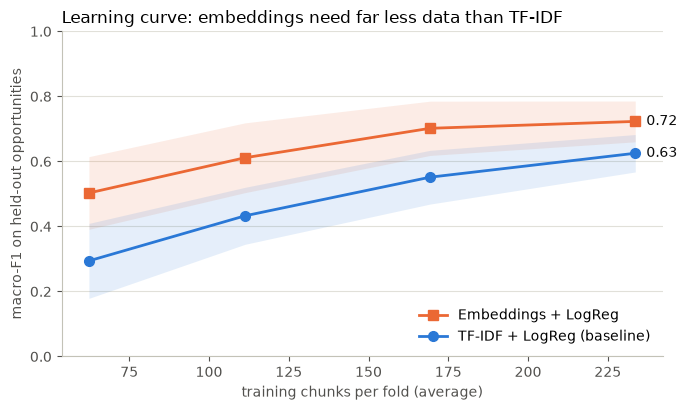

In [19]:
# ---- Learning curve: would more annotated data help? ----
# For each CV fold, train on a random 25 / 50 / 75 / 100 % of that fold's training
# *opportunities* (whole calls, never single chunks, same logic as the grouped CV), then
# score on the untouched test fold. Each smaller share is drawn 5 times with different
# seeds and averaged, so one lucky or unlucky subset doesn't decide the point.
import matplotlib.pyplot as plt
from sklearn.base import clone

FRACTIONS = [0.25, 0.5, 0.75, 1.0]
N_DRAWS = 5

# the two tuned models from above, with the hyperparameters their grid searches picked
curve_models = {
    "TF-IDF + LogReg (baseline)": (grid.best_estimator_, X_text),
    "Embeddings + LogReg": (emb_grid.best_estimator_, X_emb),
}

curve_rows = []
for name, (estimator, X_all) in curve_models.items():
    for frac in FRACTIONS:
        for fold, (train_idx, test_idx) in enumerate(cv.split(X_text, y, groups)):
            for draw in range(N_DRAWS if frac < 1 else 1):  # 100% has only one possible "subset"
                rng = np.random.default_rng(draw)
                train_opps = groups.iloc[train_idx].unique()
                kept = rng.choice(train_opps, size=round(frac * len(train_opps)), replace=False)
                sub_idx = train_idx[groups.iloc[train_idx].isin(kept).to_numpy()]

                model = clone(estimator).fit(X_all[sub_idx] if isinstance(X_all, np.ndarray) else X_all.iloc[sub_idx],
                                             y.iloc[sub_idx])
                X_test = X_all[test_idx] if isinstance(X_all, np.ndarray) else X_all.iloc[test_idx]
                curve_rows.append({
                    "model": name, "fraction": frac, "train_chunks": len(sub_idx),
                    # zero_division=0: a small subset can miss a class entirely - that
                    # class then scores 0, which is exactly the cost of too little data
                    "macro_f1": f1_score(y.iloc[test_idx], model.predict(X_test),
                                         labels=LABEL_ORDER, average="macro", zero_division=0),
                })

curve = (pd.DataFrame(curve_rows)
         .groupby(["model", "fraction"])
         .agg(train_chunks=("train_chunks", "mean"), mean_f1=("macro_f1", "mean"), std_f1=("macro_f1", "std"))
         .reset_index())
print(curve.round(3).to_string(index=False))

# ---- plot: one line per model, shaded band = +/- 1 std across folds and draws ----
COLORS = {"TF-IDF + LogReg (baseline)": "#2a78d6", "Embeddings + LogReg": "#eb6834"}  # validated pair (CVD-safe)
MARKERS = {"TF-IDF + LogReg (baseline)": "o", "Embeddings + LogReg": "s"}               # second cue beside colour

fig, ax = plt.subplots(figsize=(7, 4.2))
for name, part in curve.groupby("model"):
    ax.fill_between(part["train_chunks"], part["mean_f1"] - part["std_f1"], part["mean_f1"] + part["std_f1"],
                    color=COLORS[name], alpha=0.12, linewidth=0)
    ax.plot(part["train_chunks"], part["mean_f1"], color=COLORS[name], marker=MARKERS[name],
            markersize=7, linewidth=2, label=name)
    last = part.iloc[-1]  # direct label at the line end, in text colour (not the series colour)
    ax.annotate(f"{last['mean_f1']:.2f}", (last["train_chunks"], last["mean_f1"]),
                xytext=(8, 0), textcoords="offset points", va="center", color="#0b0b0b", fontsize=10)

ax.set_xlabel("training chunks per fold (average)", color="#52514e")
ax.set_ylabel("macro-F1 on held-out opportunities", color="#52514e")
ax.set_title("Learning curve: embeddings need far less data than TF-IDF", loc="left", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)  # recessive horizontal grid only
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# Reading it:
#  - embeddings with ~half the data (~110 chunks, 0.61) nearly match TF-IDF with all of it
#    (0.63), and beat it from ~170 chunks on (0.70)
#  - the embeddings curve flattens (+0.11, then +0.09, then +0.02 per step): doubling the
#    annotations would plausibly add a few points, not transform the result
#  - a targeted top-up of the weakest classes (EDUCATION, NATIONALITY) would likely pay
#    off more per labeled chunk than random new annotation


## Conclusion

*Snapshot of the results on the committed annotation file; everything above is deterministic, and model 4 reads its answers from the cache.*

| Model | Mean macro-F1 (5 folds) |
|---|---|
| TF-IDF + LogReg (baseline) | 0.625 |
| TF-IDF + Linear SVM | 0.643 |
| **Embeddings + LogReg** | **0.723** |
| *OpenAI LLM, few-shot (reference)* | *0.766* |

**Answer to RQ1: yes.** A trained model identifies the eligibility requirement stated in a chunk with 0.723 macro-F1 across 9 classes, validated on opportunities it never saw during training.

**Chosen model: embeddings + Logistic Regression.**
- It beats both TF-IDF models on all 5 folds.
- Its gains land where the TF-IDF error analysis predicted: DISCIPLINE (0.55 → 0.75) and NONE (0.47 → 0.58), which TF-IDF can't separate by counting words.
- LogReg instead of an SVM on the embeddings: slightly better (0.723 vs 0.704), and it gives probabilities, so the product can send low-confidence labels to human review.

**The LLM reference.** A local model with zero per-call cost and fully repeatable answers gets within about 0.04 macro-F1 of a hosted LLM that needed no training data. That puts a number on the product's design choice: about 0.04 F1 traded for determinism, zero cost and local execution. The LLM is also ahead on only 3 of 5 folds.

**Limitations.**
- Small corpus: 292 chunks, about 60 per test fold, so differences of a few points are within fold-to-fold noise.
- More data would help, but modestly: the learning curve flattens (+0.11, +0.09, then only +0.02 for the last quarter of the data), so doubling the annotations would plausibly add a few points. A targeted top-up of the weakest classes (EDUCATION, NATIONALITY) is the efficient version.
- Single annotator, and most labels were applied by an LLM session following the guidelines, then spot-checked. This may also inflate the LLM reference's score (agreement bias).
- The label audit only reviewed chunks the model got wrong, so the post-audit scores are slightly optimistic.
- Section headings were excluded from the training data, so the production chunker must drop them before classification.

